In [103]:
!pip install optuna statsforecast -q

import numpy as np
import pandas as pd
import optuna

from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, MSTL, Naive

optuna.logging.set_verbosity(optuna.logging.WARNING)


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [104]:
sum(df['Close THYAO.IS'].isna())

0

In [105]:

TICKER = "THYAO.IS"    
START_DATE = "2018-01-01"
END_DATE = "2026-05-01"

raw = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=False
)

if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [ ' '.join(col_tuple) for col_tuple in raw.columns.to_flat_index()]


raw = raw.dropna()


display(raw.head())
display(raw.tail())
print("Veri boyutu:", raw.shape)

raw = raw.asfreq("D")
raw = raw.ffill()

print(sum(raw['Close THYAO.IS'].isna()))

display(raw.head())
display(raw.tail())
print("Veri boyutu:", raw.shape)

,Close THYAO.IS,High THYAO.IS,Low THYAO.IS,Open THYAO.IS,Volume THYAO.IS
Date,,,,,
2018-01-01,15.327312,15.327312,15.327312,15.327312,0
2018-01-02,15.708297,15.805986,15.307774,15.425000,44253261
2018-01-03,15.825525,15.854831,15.551997,15.678991,40100544
2018-01-04,15.913444,16.128357,15.805986,15.825524,54106099
2018-01-05,15.952518,16.167431,15.805985,16.059975,55516943


,Close THYAO.IS,High THYAO.IS,Low THYAO.IS,Open THYAO.IS,Volume THYAO.IS
Date,,,,,
2026-04-24,325.00,326.25,319.00,323.00,37892432
2026-04-27,320.50,326.75,320.25,324.50,39753416
2026-04-28,315.75,320.25,315.25,319.50,27040131
2026-04-29,314.50,317.75,313.00,316.75,30230456
2026-04-30,308.25,311.50,305.25,310.00,55904761


Veri boyutu: (2106, 5)
0


,Close THYAO.IS,High THYAO.IS,Low THYAO.IS,Open THYAO.IS,Volume THYAO.IS
Date,,,,,
2018-01-01,15.327312,15.327312,15.327312,15.327312,0.0
2018-01-02,15.708297,15.805986,15.307774,15.425000,44253261.0
2018-01-03,15.825525,15.854831,15.551997,15.678991,40100544.0
2018-01-04,15.913444,16.128357,15.805986,15.825524,54106099.0
2018-01-05,15.952518,16.167431,15.805985,16.059975,55516943.0


,Close THYAO.IS,High THYAO.IS,Low THYAO.IS,Open THYAO.IS,Volume THYAO.IS
Date,,,,,
2026-04-26,325.00,326.25,319.00,323.00,37892432.0
2026-04-27,320.50,326.75,320.25,324.50,39753416.0
2026-04-28,315.75,320.25,315.25,319.50,27040131.0
2026-04-29,314.50,317.75,313.00,316.75,30230456.0
2026-04-30,308.25,311.50,305.25,310.00,55904761.0


Veri boyutu: (3042, 5)


In [106]:

X = raw.copy()
y = raw["Close THYAO.IS"].shift(-1)  # Hedef değişkeni bir sonraki günün kapanış fiyatı olarak ayarla

X = X[:-1]  # Son satırı çıkar (hedef değişkeni kayar)
print(X.head())
print("ML veri boyutu:", X.shape)

            Close THYAO.IS  High THYAO.IS  Low THYAO.IS  Open THYAO.IS  \
Date                                                                     
2018-01-01       15.327312      15.327312     15.327312      15.327312   
2018-01-02       15.708297      15.805986     15.307774      15.425000   
2018-01-03       15.825525      15.854831     15.551997      15.678991   
2018-01-04       15.913444      16.128357     15.805986      15.825524   
2018-01-05       15.952518      16.167431     15.805985      16.059975   

            Volume THYAO.IS  
Date                         
2018-01-01              0.0  
2018-01-02       44253261.0  
2018-01-03       40100544.0  
2018-01-04       54106099.0  
2018-01-05       55516943.0  
ML veri boyutu: (3041, 5)


In [107]:
def directional_accuracy(y_true, y_pred):
    """
    Fiyatın yönünü doğru tahmin etme oranı.
    Bugünden yarına artış/azalış yönü üzerinden hesaplanır.
    """
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    true_direction = np.sign(y_true.diff().dropna())
    pred_direction = np.sign(y_pred.diff().dropna())

    return (true_direction.values == pred_direction.values).mean()


def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100

    try:
        r2 = r2_score(y_true, y_pred)
    except:
        r2 = np.nan

    da = directional_accuracy(y_true, y_pred)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "R2": r2,
        "Directional Accuracy": da
    }

In [108]:
def make_statsforecast_df(series, unique_id="asset"):
    sf_df = pd.DataFrame({
        "unique_id": unique_id,
        "ds": pd.to_datetime(series.index),
        "y": series.values
    })

    return sf_df

In [109]:
def forecast_autoarima_statsforecast(
    train_series,
    horizon,
    freq="D",
    season_length=5
):
    sf_train = make_statsforecast_df(train_series)

    models = [
        AutoARIMA(
            season_length=season_length
        )
    ]

    sf = StatsForecast(
        models=models,
        freq=freq,
        n_jobs=-1,
        fallback_model=Naive()
    )

    forecast_df = sf.forecast(
        df=sf_train,
        h=horizon
    )

    return forecast_df["AutoARIMA"].values

In [110]:
def forecast_mstl_autoarima_statsforecast(
    train_series,
    horizon,
    freq="D",
    season_lengths=[7, 30]
):
    sf_train = make_statsforecast_df(train_series)

    models = [
        MSTL(
            season_length=season_lengths,
            trend_forecaster=AutoARIMA()
        )
    ]

    sf = StatsForecast(
        models=models,
        freq=freq,
        n_jobs=-1,
        fallback_model=Naive()
    )

    forecast_df = sf.forecast(
        df=sf_train,
        h=horizon
    )

    return forecast_df["MSTL"].values       

In [111]:
def optuna_exponential_smoothing(
    train_series,
    val_size=30,
    n_trials=30
):
    if len(train_series) <= val_size + 60:
        val_size = max(10, int(len(train_series) * 0.2))

    inner_train = train_series.iloc[:-val_size]
    val = train_series.iloc[-val_size:]

    def objective(trial):
        trend = trial.suggest_categorical("trend", [None, "add", "mul"])
        seasonal = trial.suggest_categorical("seasonal", [None, "add", "mul"])
        seasonal_periods = trial.suggest_categorical(
            "seasonal_periods",
            [None, 5, 7, 21, 30]
        )

        if seasonal is None and seasonal_periods is not None:
            raise optuna.exceptions.TrialPruned()

        if seasonal is not None and seasonal_periods is None:
            raise optuna.exceptions.TrialPruned()

        if trend == "mul" or seasonal == "mul":
            if (inner_train <= 0).any():
                raise optuna.exceptions.TrialPruned()

        if seasonal is not None:
            if len(inner_train) < seasonal_periods * 2:
                raise optuna.exceptions.TrialPruned()

        try:
            model = ExponentialSmoothing(
                inner_train,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=seasonal_periods,
                initialization_method="estimated"
            ).fit(optimized=True)

            pred = model.forecast(len(val))
            rmse = np.sqrt(mean_squared_error(val, pred))

            return rmse

        except Exception:
            raise optuna.exceptions.TrialPruned()

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    return study.best_params, study.best_value

In [112]:
def optuna_random_forest(
    X_train,
    y_train,
    val_size=30,
    n_trials=30
):
    if len(X_train) <= val_size + 60:
        val_size = max(10, int(len(X_train) * 0.2))

    X_inner_train = X_train.iloc[:-val_size]
    y_inner_train = y_train.iloc[:-val_size]

    X_val = X_train.iloc[-val_size:]
    y_val = y_train.iloc[-val_size:]

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=100),
            "max_depth": trial.suggest_categorical("max_depth", [3, 5, 8, 12, None]),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", 0.5, 0.7, 1.0])
        }

        model = RandomForestRegressor(
            **params,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_inner_train, y_inner_train)
        pred = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, pred))

        return rmse

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    return study.best_params, study.best_value

In [113]:
def optuna_hgb(
    X_train,
    y_train,
    val_size=30,
    n_trials=30
):
    if len(X_train) <= val_size + 60:
        val_size = max(10, int(len(X_train) * 0.2))

    X_inner_train = X_train.iloc[:-val_size]
    y_inner_train = y_train.iloc[:-val_size]

    X_val = X_train.iloc[-val_size:]
    y_val = y_train.iloc[-val_size:]

    def objective(trial):
        params = {
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.005,
                0.15,
                log=True
            ),
            "max_leaf_nodes": trial.suggest_categorical(
                "max_leaf_nodes",
                [7, 15, 31, 63]
            ),
            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                10,
                80
            ),
            "l2_regularization": trial.suggest_float(
                "l2_regularization",
                1e-6,
                1.0,
                log=True
            ),
            "max_bins": trial.suggest_categorical(
                "max_bins",
                [64, 128, 255]
            )
        }

        model = HistGradientBoostingRegressor(
            **params,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=30,
            tol=1e-7,
            random_state=42
        )

        model.fit(X_inner_train, y_inner_train)
        pred = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, pred))

        return rmse

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_score = study.best_value

    return best_params, best_score

In [114]:
def time_series_benchmark(
    X,
    y,
    n_splits=5,
    test_size=60,
    val_size=30,
    freq="D",
    autoarima_season_length=5,
    mstl_season_lengths=[7, 30],
    n_trials=30
):
    results = []
    predictions_all = []

    total_len = len(X)
    fold_starts = []

    for i in range(n_splits):
        test_start = total_len - test_size * (n_splits - i)
        test_end = test_start + test_size

        if test_start <= 100:
            continue

        fold_starts.append((test_start, test_end))

    for fold, (test_start, test_end) in enumerate(fold_starts, start=1):
        print(f"\nFold {fold} çalışıyor...")

        X_train = X.iloc[:test_start]
        y_train = y.iloc[:test_start]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        train_series = y_train.copy()

        # =====================================================
        # Model 1: StatsForecast AutoARIMA
        # =====================================================
        try:
            autoarima_pred = forecast_autoarima_statsforecast(
                train_series=train_series,
                horizon=len(y_test),
                freq=freq,
                season_length=autoarima_season_length
            )

            results.append({
                "Model": "StatsForecast AutoARIMA",
                "Fold": fold,
                "Best Params": f"season_length={autoarima_season_length}",
                **calculate_metrics(y_test, autoarima_pred)
            })

            predictions_all.append(pd.DataFrame({
                "Date": y_test.index,
                "Actual": y_test.values,
                "Prediction": autoarima_pred,
                "Model": "StatsForecast AutoARIMA",
                "Fold": fold
            }))

        except Exception as e:
            print("AutoARIMA hata verdi:", e)

        # =====================================================
        # Model 2: MSTL + AutoARIMA
        # =====================================================
        try:
            mstl_pred = forecast_mstl_autoarima_statsforecast(
                train_series=train_series,
                horizon=len(y_test),
                freq=freq,
                season_lengths=mstl_season_lengths
            )

            results.append({
                "Model": "MSTL + AutoARIMA",
                "Fold": fold,
                "Best Params": f"season_lengths={mstl_season_lengths}",
                **calculate_metrics(y_test, mstl_pred)
            })

            predictions_all.append(pd.DataFrame({
                "Date": y_test.index,
                "Actual": y_test.values,
                "Prediction": mstl_pred,
                "Model": "MSTL + AutoARIMA",
                "Fold": fold
            }))

        except Exception as e:
            print("MSTL + AutoARIMA hata verdi:", e)

        # =====================================================
        # Model 3: Optuna Exponential Smoothing
        # =====================================================
        try:
            best_es_params, best_es_score = optuna_exponential_smoothing(
                train_series=train_series,
                val_size=val_size,
                n_trials=n_trials
            )

            print("Best ES Params:", best_es_params)

            es_model = ExponentialSmoothing(
                train_series,
                trend=best_es_params["trend"],
                seasonal=best_es_params["seasonal"],
                seasonal_periods=best_es_params["seasonal_periods"],
                initialization_method="estimated"
            ).fit(optimized=True)

            es_pred = es_model.forecast(len(y_test))

            results.append({
                "Model": "Optuna Exponential Smoothing",
                "Fold": fold,
                "Best Params": str(best_es_params),
                **calculate_metrics(y_test, es_pred)
            })

            predictions_all.append(pd.DataFrame({
                "Date": y_test.index,
                "Actual": y_test.values,
                "Prediction": np.asarray(es_pred),
                "Model": "Optuna Exponential Smoothing",
                "Fold": fold
            }))

        except Exception as e:
            print("Optuna Exponential Smoothing hata verdi:", e)

        # =====================================================
        # Model 4: Optuna Random Forest
        # =====================================================
        try:
            best_rf_params, best_rf_score = optuna_random_forest(
                X_train=X_train,
                y_train=y_train,
                val_size=val_size,
                n_trials=n_trials
            )

            print("Best RF Params:", best_rf_params)

            rf = RandomForestRegressor(
                **best_rf_params,
                random_state=42,
                n_jobs=-1
            )

            rf.fit(X_train, y_train)
            rf_pred = rf.predict(X_test)

            results.append({
                "Model": "Optuna Random Forest",
                "Fold": fold,
                "Best Params": str(best_rf_params),
                **calculate_metrics(y_test, rf_pred)
            })

            predictions_all.append(pd.DataFrame({
                "Date": y_test.index,
                "Actual": y_test.values,
                "Prediction": rf_pred,
                "Model": "Optuna Random Forest",
                "Fold": fold
            }))

        except Exception as e:
            print("Optuna Random Forest hata verdi:", e)

        # =====================================================
        # Model 5: Optuna HistGradientBoosting with Early Stopping
        # =====================================================
        try:
            best_hgb_params, best_hgb_score = optuna_hgb(
                X_train=X_train,
                y_train=y_train,
                val_size=val_size,
                n_trials=n_trials
            )

            print("Best HGB Params:", best_hgb_params)

            hgb = HistGradientBoostingRegressor(
                **best_hgb_params,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.2,
                n_iter_no_change=30,
                tol=1e-7,
                random_state=42
            )

            hgb.fit(X_train, y_train)
            hgb_pred = hgb.predict(X_test)

            results.append({
                "Model": "Optuna HistGradientBoosting EarlyStopping",
                "Fold": fold,
                "Best Params": str(best_hgb_params),
                "Actual Iterations": hgb.n_iter_,
                **calculate_metrics(y_test, hgb_pred)
            })

            predictions_all.append(pd.DataFrame({
                "Date": y_test.index,
                "Actual": y_test.values,
                "Prediction": hgb_pred,
                "Model": "Optuna HistGradientBoosting EarlyStopping",
                "Fold": fold
            }))

        except Exception as e:
            print("Optuna HistGradientBoosting hata verdi:", e)

    results_df = pd.DataFrame(results)

    if len(predictions_all) > 0:
        predictions_df = pd.concat(predictions_all, ignore_index=True)
    else:
        predictions_df = pd.DataFrame()

    summary = (
        results_df
        .groupby("Model")
        .agg({
            "RMSE": ["mean", "std"],
            "MAE": ["mean", "std"],
            "MAPE (%)": ["mean", "std"],
            "R2": ["mean", "std"],
            "Directional Accuracy": ["mean", "std"]
        })
        .round(4)
    )

    return results_df, summary, predictions_df

In [115]:
results_df, summary, predictions_df = time_series_benchmark(
    X=X,
    y=y,
    n_splits=5,
    test_size=80,
    val_size=10,
)

display(results_df)
display(summary)


Fold 1 çalışıyor...
Best ES Params: {'trend': None, 'seasonal': None, 'seasonal_periods': None}
Best RF Params: {'n_estimators': 600, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'max_features': 'sqrt'}
Best HGB Params: {'learning_rate': 0.005379733256186882, 'max_leaf_nodes': 15, 'min_samples_leaf': 80, 'l2_regularization': 0.0003647805271728408, 'max_bins': 128}

Fold 2 çalışıyor...
Best ES Params: {'trend': None, 'seasonal': 'mul', 'seasonal_periods': 30}
Best RF Params: {'n_estimators': 600, 'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 11, 'max_features': 1.0}
Best HGB Params: {'learning_rate': 0.024256390691135395, 'max_leaf_nodes': 31, 'min_samples_leaf': 69, 'l2_regularization': 4.4348789403658665e-06, 'max_bins': 64}

Fold 3 çalışıyor...
Best ES Params: {'trend': None, 'seasonal': 'mul', 'seasonal_periods': 21}
Best RF Params: {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 8, 'max_features': 1.0}
Best HGB Par

,Model,Fold,Best Params,RMSE,MAE,MAPE (%),R2,Directional Accuracy,Actual Iterations
0,StatsForecast AutoARIMA,1,season_length=5,221.902449,193.501826,68.524554,-214.503911,0.278481,NaN
1,MSTL + AutoARIMA,1,"season_lengths=[7, 30]",27.240262,21.900623,7.849538,-2.247533,0.392405,NaN
2,Optuna Exponential Smoothing,1,"{'trend': None, 'seasonal': None, 'seasonal_pe...",19.603593,15.780809,5.646042,-0.681908,0.392405,NaN
3,Optuna Random Forest,1,"{'n_estimators': 600, 'max_depth': 5, 'min_sam...",5.490811,3.805478,1.332413,0.868052,0.405063,NaN
4,Optuna HistGradientBoosting EarlyStopping,1,"{'learning_rate': 0.005379733256186882, 'max_l...",5.340213,3.582854,1.254372,0.875190,0.417722,1000.0
5,StatsForecast AutoARIMA,2,season_length=5,38.962987,32.406042,10.416926,-1.320270,0.392405,NaN
6,MSTL + AutoARIMA,2,"season_lengths=[7, 30]",42.770546,36.183167,11.670204,-1.795912,0.354430,NaN
7,Optuna Exponential Smoothing,2,"{'trend': None, 'seasonal': 'mul', 'seasonal_p...",45.855071,38.723770,12.474033,-2.213725,0.367089,NaN
8,Optuna Random Forest,2,"{'n_estimators': 600, 'max_depth': 12, 'min_sa...",5.666016,4.100052,1.366421,0.950933,0.493671,NaN
9,Optuna HistGradientBoosting EarlyStopping,2,"{'learning_rate': 0.024256390691135395, 'max_l...",12.139907,8.479189,2.713775,0.774750,0.392405,707.0


RMSE               MAE           \
                                              mean      std     mean      std   
Model                                                                           
MSTL + AutoARIMA                           31.1428   9.9907  25.8538   9.3510   
Optuna Exponential Smoothing               28.9908  11.2794  23.8068  10.4361   
Optuna HistGradientBoosting EarlyStopping   7.1787   3.3090   5.0476   2.2023   
Optuna Random Forest                        5.4993   0.8581   3.8770   0.5958   
StatsForecast AutoARIMA                    68.5616  86.1371  58.5417  75.8648   

                                          MAPE (%)                R2           \
                                              mean      std     mean      std   
Model                                                                           
MSTL + AutoARIMA                            8.7329   3.0251  -1.8830   1.2455   
Optuna Exponential Smoothing                7.9987   3.2807  -1.3721   0.9050   
Optuna HistGradientBoosting EarlyStopping   1.6555   0.6628   0.8530   0.0755   
Optuna Random Forest                        1.2955   0.1747   0.9059   0.0362   
StatsForecast AutoARIMA                    20.3244  27.0725 -44.0807  95.2750   

                                          Directional Accuracy          
                                                          mean     std  
Model                                                                   
MSTL + AutoARIMA                                        0.3595  0.0549  
Optuna Exponential Smoothing                            0.3570  0.0394  
Optuna HistGradientBoosting EarlyStopping               0.4228  0.0342  
Optuna Random Forest                                    0.4253  0.0426  
StatsForecast AutoARIMA                                 0.3316  0.0865

In [120]:
ranking = (
    results_df
    .groupby("Model")
    .agg({
        "RMSE": "mean",
        "MAE": "mean",
        "MAPE (%)": "mean",
        "Directional Accuracy": "mean"
    })
    .sort_values("RMSE")
    .round(4)
)

display(ranking)

best_model_name = ranking.index[0]
print("RMSE'ye göre en iyi model:", best_model_name)

,RMSE,MAE,MAPE (%),Directional Accuracy
Model,,,,
Optuna Random Forest,5.4993,3.8770,1.2955,0.4253
Optuna HistGradientBoosting EarlyStopping,7.1787,5.0476,1.6555,0.4228
Optuna Exponential Smoothing,28.9908,23.8068,7.9987,0.3570
MSTL + AutoARIMA,31.1428,25.8538,8.7329,0.3595
StatsForecast AutoARIMA,68.5616,58.5417,20.3244,0.3316


RMSE'ye göre en iyi model: Optuna Random Forest


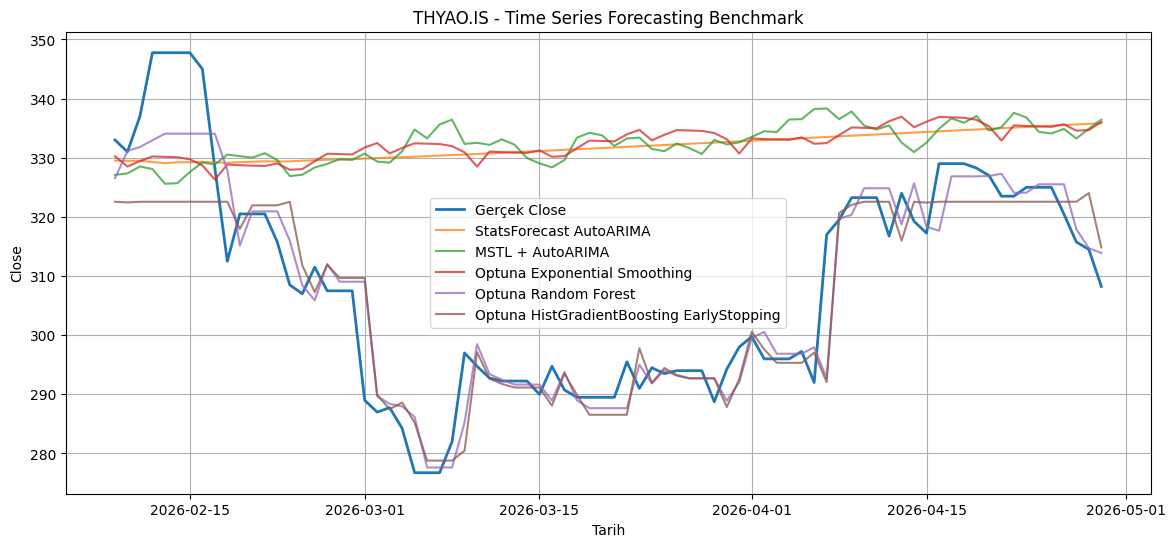

In [121]:
last_fold = predictions_df["Fold"].max()

plot_df = predictions_df[
    (predictions_df["Fold"] == last_fold)
].copy()

plt.figure(figsize=(14, 6))

actual_df = plot_df.drop_duplicates(subset=["Date"])[["Date", "Actual"]]

plt.plot(actual_df["Date"], actual_df["Actual"], label="Gerçek Close", linewidth=2)

for model_name in plot_df["Model"].unique():
    temp = plot_df[plot_df["Model"] == model_name]
    plt.plot(temp["Date"], temp["Prediction"], label=model_name, alpha=0.75)

plt.title(f"{TICKER} - Time Series Forecasting Benchmark")
plt.xlabel("Tarih")
plt.ylabel("Close")
plt.legend()
plt.grid(True)
plt.show()

In [118]:
results_df.to_csv("../outputs/time_series_benchmark_fold_results.csv", index=False)
ranking.to_csv("../outputs/time_series_benchmark_ranking.csv")

print("CSV dosyaları kaydedildi.")

CSV dosyaları kaydedildi.


In [128]:
!pip install  mlforecast 



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [129]:
# !pip install yfinance optuna statsforecast mlforecast scikit-learn tqdm

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import optuna

from tqdm.auto import tqdm

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, MSTL

from mlforecast import MLForecast
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

ticker = "AAPL"
n_trials = 40

print(f"[1/7] Downloading OHLCV data for {ticker}...")

raw = yf.download(
    ticker,
    period="5y",
    auto_adjust=False,
    progress=False,
)

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw.reset_index()

date_col = "Date" if "Date" in df.columns else "Datetime"

df = df[[date_col, "Open", "High", "Low", "Close", "Volume"]].copy()
df = df.rename(columns={date_col: "ds"})

df["unique_id"] = ticker
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds").reset_index(drop=True)

print(f"Downloaded rows: {len(df):,}")
print(f"Date range: {df['ds'].min().date()} -> {df['ds'].max().date()}")
print(df.tail())

# -----------------------------
# 2. StatsForecast
# -----------------------------
print("\n[2/7] Preparing StatsForecast data...")

sf_df = df[["unique_id", "ds", "Close"]].copy()
sf_df = sf_df.rename(columns={"Close": "y"})

print("StatsForecast columns:", list(sf_df.columns))
print(sf_df.tail())

print("\n[3/7] Fitting StatsForecast models: AutoARIMA + MSTL(AutoARIMA)...")

sf = StatsForecast(
    models=[
        AutoARIMA(season_length=5),
        MSTL(
            season_length=[5, 20, 50, 200],
            trend_forecaster=AutoARIMA(season_length=1),
        ),
    ],
    freq="B",
    n_jobs=-1,
)

statsforecast_pred = sf.forecast(df=sf_df, h=1)

print("\nStatsForecast next-day forecast:")
print(statsforecast_pred)

# -----------------------------
# 3. Supervised next-day Close forecasting
# -----------------------------
print("\n[4/7] Building supervised dataset using previous-day OHLCV only...")

supervised = df.copy()

for col in tqdm(["Open", "High", "Low", "Close", "Volume"], desc="Creating previous-day columns"):
    supervised[f"prev_{col}"] = supervised[col].shift(1)

supervised = supervised.dropna().reset_index(drop=True)

feature_cols = ["prev_Open", "prev_High", "prev_Low", "prev_Close", "prev_Volume"]
target_col = "Close"

X = supervised[feature_cols]
y = supervised[target_col]

X_next = df[["Open", "High", "Low", "Close", "Volume"]].tail(1)
X_next.columns = feature_cols

print(f"Supervised rows: {len(supervised):,}")
print("Features:", feature_cols)
print("Target:", target_col)
print("\nLatest previous-day OHLCV used for next forecast:")
print(X_next)

# -----------------------------
# 4. Optuna tuning helpers
# -----------------------------
def cv_objective(model_factory, trial):
    """Use time series CV for non-boosting linear/tree models."""
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = model_factory(trial)
        model.fit(X_train, y_train)

        pred = model.predict(X_valid)
        mae = mean_absolute_error(y_valid, pred)
        scores.append(mae)

    return float(np.mean(scores))


def holdout_objective(model_factory, trial):
    """Use one validation split for boosting models with early stopping."""
    split = int(len(X) * 0.8)

    X_train, X_valid = X.iloc[:split], X.iloc[split:]
    y_train, y_valid = y.iloc[:split], y.iloc[split:]

    model = model_factory(trial)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return mean_absolute_error(y_valid, pred)


# -----------------------------
# 5. Model factories
# -----------------------------
def ridge_factory(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 100.0, log=True)
    return make_pipeline(StandardScaler(), Ridge(alpha=alpha))


def elasticnet_factory(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.05, 0.95)
    return make_pipeline(
        StandardScaler(),
        ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20_000),
    )


def random_forest_factory(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        max_depth=trial.suggest_int("max_depth", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        random_state=42,
        n_jobs=-1,
    )


def extra_trees_factory(trial):
    return ExtraTreesRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        max_depth=trial.suggest_int("max_depth", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        random_state=42,
        n_jobs=-1,
    )


def gradient_boosting_factory(trial):
    return GradientBoostingRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 2000),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        validation_fraction=0.2,
        n_iter_no_change=30,
        tol=1e-4,
        random_state=42,
    )


def hist_gradient_boosting_factory(trial):
    return HistGradientBoostingRegressor(
        max_iter=trial.suggest_int("max_iter", 100, 2000),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 8, 64),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-8, 10.0, log=True),
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=30,
        random_state=42,
    )


model_specs = {
    "Ridge": (ridge_factory, cv_objective),
    "ElasticNet": (elasticnet_factory, cv_objective),
    "RandomForest": (random_forest_factory, cv_objective),
    "ExtraTrees": (extra_trees_factory, cv_objective),
    "GradientBoosting": (gradient_boosting_factory, holdout_objective),
    "HistGradientBoosting": (hist_gradient_boosting_factory, holdout_objective),
}

# -----------------------------
# 6. Tune, fit, and forecast
# -----------------------------
print("\n[5/7] Starting Optuna tuning...")

results = []

for name, (factory, objective_fn) in tqdm(model_specs.items(), desc="Models"):
    print(f"\nTuning model: {name}")
    print("-" * 60)

    trial_bar = tqdm(total=n_trials, desc=f"{name} trials", leave=False)

    def objective_with_progress(trial):
        score = objective_fn(factory, trial)
        trial_bar.update(1)
        trial_bar.set_postfix(best=f"{score:.4f}")
        return score

    study = optuna.create_study(direction="minimize")
    study.optimize(
        objective_with_progress,
        n_trials=n_trials,
        show_progress_bar=False,
    )

    trial_bar.close()

    print(f"Best MAE for {name}: {study.best_value:.6f}")
    print(f"Best params for {name}: {study.best_params}")

    print(f"Refitting {name} on full supervised dataset...")
    best_model = factory(study.best_trial)
    best_model.fit(X, y)

    next_close = best_model.predict(X_next)[0]

    print(f"{name} next-day Close forecast: {next_close:.4f}")

    results.append(
        {
            "model": name,
            "best_mae": study.best_value,
            "next_day_close_forecast": next_close,
            "best_params": study.best_params,
        }
    )

sklearn_results = pd.DataFrame(results).sort_values("best_mae")

print("\nSklearn / Optuna next-day forecasts:")
print(sklearn_results[["model", "best_mae", "next_day_close_forecast"]])

# -----------------------------
# 7. MLForecast wrapper
# -----------------------------
print("\n[6/7] Fitting MLForecast model with lag-1 Close only...")

mlf_df = df[["unique_id", "ds", "Close"]].rename(columns={"Close": "y"})

mlf = MLForecast(
    models={
        "rf_lag1": RandomForestRegressor(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        )
    },
    freq="B",
    lags=[1],
    date_features=[],
)

mlf.fit(mlf_df)
mlforecast_pred = mlf.predict(h=1)

print("\nMLForecast lag-1 Close forecast:")
print(mlforecast_pred)

# -----------------------------
# 8. Combined forecast table
# -----------------------------
print("\n[7/7] Combined forecast summary...")

stats_long = statsforecast_pred.melt(
    id_vars=["unique_id", "ds"],
    var_name="model",
    value_name="next_day_close_forecast",
)

stats_long["source"] = "StatsForecast"
stats_long["best_mae"] = np.nan

sklearn_long = sklearn_results.copy()
sklearn_long["source"] = "Sklearn + Optuna"
sklearn_long["unique_id"] = ticker
sklearn_long["ds"] = statsforecast_pred["ds"].iloc[0]

mlf_long = mlforecast_pred.melt(
    id_vars=["unique_id", "ds"],
    var_name="model",
    value_name="next_day_close_forecast",
)

mlf_long["source"] = "MLForecast"
mlf_long["best_mae"] = np.nan

combined = pd.concat(
    [
        stats_long[["source", "model", "unique_id", "ds", "best_mae", "next_day_close_forecast"]],
        sklearn_long[["source", "model", "unique_id", "ds", "best_mae", "next_day_close_forecast"]],
        mlf_long[["source", "model", "unique_id", "ds", "best_mae", "next_day_close_forecast"]],
    ],
    ignore_index=True,
)

print(combined.sort_values(["source", "best_mae"], na_position="last"))


[1/7] Downloading OHLCV data for AAPL...
Downloaded rows: 1,255
Date range: 2021-05-05 -> 2026-05-04
Price         ds        Open        High         Low       Close    Volume  \
1250  2026-04-28  272.339996  273.230011  268.660004  270.709991  40018900   
1251  2026-04-29  267.549988  271.040009  267.040009  270.170013  30047900   
1252  2026-04-30  270.500000  276.000000  268.140015  271.350006  91848200   
1253  2026-05-01  278.859985  287.220001  278.369995  280.140015  79844600   
1254  2026-05-04  279.654999  280.630005  274.860107  276.829987  45414226   

Price unique_id  
1250       AAPL  
1251       AAPL  
1252       AAPL  
1253       AAPL  
1254       AAPL  

[2/7] Preparing StatsForecast data...
StatsForecast columns: ['unique_id', 'ds', 'y']
Price unique_id         ds           y
1250       AAPL 2026-04-28  270.709991
1251       AAPL 2026-04-29  270.170013
1252       AAPL 2026-04-30  271.350006
1253       AAPL 2026-05-01  280.140015
1254       AAPL 2026-05-04  276.829987



Creating previous-day columns:   0%|          | 0/5 [00:00<?, ?it/s]

Supervised rows: 1,254
Features: ['prev_Open', 'prev_High', 'prev_Low', 'prev_Close', 'prev_Volume']
Target: Close

Latest previous-day OHLCV used for next forecast:
       prev_Open   prev_High    prev_Low  prev_Close  prev_Volume
1254  279.654999  280.630005  274.860107  276.829987     45414226

[5/7] Starting Optuna tuning...


Models:   0%|          | 0/6 [00:00<?, ?it/s]


Tuning model: Ridge
------------------------------------------------------------


...

GradientBoosting trials:   0%|          | 0/40 [00:00<?, ?it/s]

Best MAE for GradientBoosting: 7.564022
Best params for GradientBoosting: {'n_estimators': 736, 'learning_rate': 0.17708811615793227, 'max_depth': 3, 'subsample': 0.7035009012454578}
Refitting GradientBoosting on full supervised dataset...
GradientBoosting next-day Close forecast: 276.9581

Tuning model: HistGradientBoosting
------------------------------------------------------------


HistGradientBoosting trials:   0%|          | 0/40 [00:00<?, ?it/s]

Best MAE for HistGradientBoosting: 8.881076
Best params for HistGradientBoosting: {'max_iter': 1888, 'learning_rate': 0.19863279035475084, 'max_leaf_nodes': 50, 'min_samples_leaf': 7, 'l2_regularization': 4.638705217212332}
Refitting HistGradientBoosting on full supervised dataset...
HistGradientBoosting next-day Close forecast: 280.5902

Sklearn / Optuna next-day forecasts:
                  model  best_mae  next_day_close_forecast
0                 Ridge  2.442521               276.838196
1            ElasticNet  2.444154               276.822868
3            ExtraTrees  5.839550               276.493389
2          RandomForest  5.974084               277.695249
4      GradientBoosting  7.564022               276.958096
5  HistGradientBoosting  8.881076               280.590165

[6/7] Fitting MLForecast model with lag-1 Close only...


ValueError: Series contain missing or duplicate timestamps with the specified freq B
Affected series: ['AAPL']
Consider using the fill_gaps parameter or preprocessing your data.

In [131]:
# !pip install yfinance optuna statsforecast mlforecast scikit-learn tqdm

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import optuna

from tqdm.auto import tqdm

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, MSTL

from mlforecast import MLForecast

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# -----------------------------
# Config
# -----------------------------
ticker = "AAPL"
period = "5y"

train_size = 0.70
val_size = 0.15
test_size = 0.15

n_trials = 40
random_state = 42

# -----------------------------
# Metrics
# -----------------------------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)

    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100


def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / np.asarray(y_true))) * 100

    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "smape": smape(y_true, y_pred),
    }


# -----------------------------
# 1. Download data
# -----------------------------
print(f"[1/8] Downloading {ticker} OHLCV data...")

raw = yf.download(
    ticker,
    period=period,
    auto_adjust=False,
    progress=False,
)

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw.reset_index()

date_col = "Date" if "Date" in df.columns else "Datetime"

df = df[[date_col, "Open", "High", "Low", "Close", "Volume"]].copy()
df = df.rename(columns={date_col: "ds"})

df["unique_id"] = ticker
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Date range: {df['ds'].min().date()} -> {df['ds'].max().date()}")

# -----------------------------
# 2. Build supervised dataset
#    y_t = Close_t
#    X_t = OHLCV_{t-1}
# -----------------------------
print("\n[2/8] Creating previous-day OHLCV supervised benchmark data...")

supervised = df.copy()

for col in tqdm(["Open", "High", "Low", "Close", "Volume"], desc="Lagging OHLCV"):
    supervised[f"prev_{col}"] = supervised[col].shift(1)

supervised = supervised.dropna().reset_index(drop=True)

feature_cols = ["prev_Open", "prev_High", "prev_Low", "prev_Close", "prev_Volume"]
target_col = "Close"

n = len(supervised)
train_end = int(n * train_size)
val_end = int(n * (train_size + val_size))

train_df = supervised.iloc[:train_end].copy()
val_df = supervised.iloc[train_end:val_end].copy()
test_df = supervised.iloc[val_end:].copy()

trainval_df = supervised.iloc[:val_end].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_trainval = trainval_df[feature_cols]
y_trainval = trainval_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Train rows: {len(train_df):,} | {train_df['ds'].min().date()} -> {train_df['ds'].max().date()}")
print(f"Val rows:   {len(val_df):,} | {val_df['ds'].min().date()} -> {val_df['ds'].max().date()}")
print(f"Test rows:  {len(test_df):,} | {test_df['ds'].min().date()} -> {test_df['ds'].max().date()}")

# -----------------------------
# 3. Model factories
# -----------------------------
def ridge_factory(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 100.0, log=True)
    return make_pipeline(StandardScaler(), Ridge(alpha=alpha))


def elasticnet_factory(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.05, 0.95)

    return make_pipeline(
        StandardScaler(),
        ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=20_000,
        ),
    )


def random_forest_factory(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        max_depth=trial.suggest_int("max_depth", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        random_state=random_state,
        n_jobs=-1,
    )


def extra_trees_factory(trial):
    return ExtraTreesRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        max_depth=trial.suggest_int("max_depth", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        random_state=random_state,
        n_jobs=-1,
    )


def gradient_boosting_factory(trial):
    return GradientBoostingRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 2000),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        validation_fraction=0.2,
        n_iter_no_change=30,
        tol=1e-4,
        random_state=random_state,
    )


def hist_gradient_boosting_factory(trial):
    return HistGradientBoostingRegressor(
        max_iter=trial.suggest_int("max_iter", 100, 2000),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 8, 64),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-8, 10.0, log=True),
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=30,
        random_state=random_state,
    )


# -----------------------------
# 4. Optuna objectives
# -----------------------------
def cv_objective(model_factory, trial):
    """
    For non-boosting linear/tree models:
    Tune with TimeSeriesSplit on train+val only.
    Test is never touched during tuning.
    """
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []

    for fold, (fit_idx, valid_idx) in enumerate(tscv.split(X_trainval), start=1):
        X_fit, X_valid = X_trainval.iloc[fit_idx], X_trainval.iloc[valid_idx]
        y_fit, y_valid = y_trainval.iloc[fit_idx], y_trainval.iloc[valid_idx]

        model = model_factory(trial)
        model.fit(X_fit, y_fit)

        pred = model.predict(X_valid)
        scores.append(mean_absolute_error(y_valid, pred))

    return float(np.mean(scores))


def boosting_objective(model_factory, trial):
    """
    For boosting models:
    Tune on train and evaluate on val.
    No cross validation.
    """
    model = model_factory(trial)
    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)


model_specs = {
    "Ridge": {
        "factory": ridge_factory,
        "objective": cv_objective,
        "fit_X": X_trainval,
        "fit_y": y_trainval,
        "uses_cv": True,
    },
    "ElasticNet": {
        "factory": elasticnet_factory,
        "objective": cv_objective,
        "fit_X": X_trainval,
        "fit_y": y_trainval,
        "uses_cv": True,
    },
    "RandomForest": {
        "factory": random_forest_factory,
        "objective": cv_objective,
        "fit_X": X_trainval,
        "fit_y": y_trainval,
        "uses_cv": True,
    },
    "ExtraTrees": {
        "factory": extra_trees_factory,
        "objective": cv_objective,
        "fit_X": X_trainval,
        "fit_y": y_trainval,
        "uses_cv": True,
    },
    "GradientBoosting": {
        "factory": gradient_boosting_factory,
        "objective": boosting_objective,
        "fit_X": X_trainval,
        "fit_y": y_trainval,
        "uses_cv": False,
    },
    "HistGradientBoosting": {
        "factory": hist_gradient_boosting_factory,
        "objective": boosting_objective,
        "fit_X": X_trainval,
        "fit_y": y_trainval,
        "uses_cv": False,
    },
}

# -----------------------------
# 5. Sklearn benchmark on test
# -----------------------------
print("\n[3/8] Running sklearn + Optuna benchmark...")

benchmark_rows = []
prediction_frames = []

for name, spec in tqdm(model_specs.items(), desc="Sklearn models"):
    print(f"\nTuning {name}")
    print(f"CV used: {spec['uses_cv']}")

    trial_bar = tqdm(total=n_trials, desc=f"{name} Optuna trials", leave=False)

    def objective_with_progress(trial):
        score = spec["objective"](spec["factory"], trial)
        trial_bar.update(1)

        best_so_far = min(
            [t.value for t in trial.study.trials if t.value is not None] + [score]
        )

        trial_bar.set_postfix(
            trial_mae=f"{score:.4f}",
            best_mae=f"{best_so_far:.4f}",
        )

        return score

    study = optuna.create_study(direction="minimize")
    study.optimize(
        objective_with_progress,
        n_trials=n_trials,
        show_progress_bar=False,
    )

    trial_bar.close()

    print(f"Best tuning MAE: {study.best_value:.6f}")
    print(f"Best params: {study.best_params}")

    final_model = spec["factory"](study.best_trial)

    print(f"Fitting final {name} on train+val...")
    final_model.fit(spec["fit_X"], spec["fit_y"])

    print(f"Running test inference for {name}...")
    test_pred = final_model.predict(X_test)

    metrics = evaluate(y_test, test_pred)

    benchmark_rows.append(
        {
            "source": "sklearn",
            "model": name,
            "uses_cv": spec["uses_cv"],
            "tuning_mae": study.best_value,
            "test_mae": metrics["mae"],
            "test_rmse": metrics["rmse"],
            "test_mape": metrics["mape"],
            "test_smape": metrics["smape"],
            "best_params": study.best_params,
        }
    )

    pred_df = test_df[["unique_id", "ds", "Close"]].copy()
    pred_df = pred_df.rename(columns={"Close": "y_true"})
    pred_df["source"] = "sklearn"
    pred_df["model"] = name
    pred_df["y_pred"] = test_pred
    pred_df["error"] = pred_df["y_true"] - pred_df["y_pred"]
    prediction_frames.append(pred_df)

# -----------------------------
# 6. StatsForecast benchmark
# -----------------------------
print("\n[4/8] Running StatsForecast rolling benchmark on test...")

sf_all = df[["unique_id", "ds", "Close"]].copy()
sf_all = sf_all.rename(columns={"Close": "y"})

test_dates = test_df["ds"].tolist()
stats_preds = []

for test_date in tqdm(test_dates, desc="StatsForecast rolling test inference"):
    history = sf_all[sf_all["ds"] < test_date].copy()

    sf = StatsForecast(
        models=[
            AutoARIMA(season_length=5),
            MSTL(
                season_length=[5, 20, 50, 200],
                trend_forecaster=AutoARIMA(season_length=1),
            ),
        ],
        freq="B",
        n_jobs=-1,
    )

    pred = sf.forecast(df=history, h=1)
    pred["target_ds"] = test_date
    stats_preds.append(pred)

stats_pred_df = pd.concat(stats_preds, ignore_index=True)

stats_model_cols = [
    col for col in stats_pred_df.columns
    if col not in ["unique_id", "ds", "target_ds"]
]

for model_col in stats_model_cols:
    aligned = test_df[["unique_id", "ds", "Close"]].copy()
    aligned = aligned.rename(columns={"Close": "y_true"})

    one_model_pred = stats_pred_df[["target_ds", model_col]].copy()
    one_model_pred = one_model_pred.rename(
        columns={
            "target_ds": "ds",
            model_col: "y_pred",
        }
    )

    aligned = aligned.merge(one_model_pred, on="ds", how="left")

    metrics = evaluate(aligned["y_true"], aligned["y_pred"])

    benchmark_rows.append(
        {
            "source": "statsforecast",
            "model": model_col,
            "uses_cv": False,
            "tuning_mae": np.nan,
            "test_mae": metrics["mae"],
            "test_rmse": metrics["rmse"],
            "test_mape": metrics["mape"],
            "test_smape": metrics["smape"],
            "best_params": None,
        }
    )

    aligned["source"] = "statsforecast"
    aligned["model"] = model_col
    aligned["error"] = aligned["y_true"] - aligned["y_pred"]
    prediction_frames.append(aligned)

# -----------------------------
# 7. MLForecast benchmark
# -----------------------------
print("\n[5/8] Running MLForecast rolling benchmark on test...")

# MLForecast freq='B' stock market holidays nedeniyle hata verebilir.
# Bu yüzden MLForecast içinde integer time index kullanıyoruz.
mlf_base = df[["unique_id", "ds", "Close"]].copy()
mlf_base = mlf_base.rename(columns={"Close": "y", "ds": "real_ds"})
mlf_base["ds"] = np.arange(len(mlf_base))

test_dates = test_df["ds"].tolist()

mlf_preds = []

for test_date in tqdm(test_dates, desc="MLForecast rolling test inference"):
    target_pos = mlf_base.loc[mlf_base["real_ds"] == test_date, "ds"].iloc[0]

    history = mlf_base[mlf_base["ds"] < target_pos][["unique_id", "ds", "y"]].copy()

    mlf = MLForecast(
        models={
            "rf_lag1": RandomForestRegressor(
                n_estimators=500,
                max_depth=8,
                min_samples_leaf=3,
                random_state=random_state,
                n_jobs=-1,
            )
        },
        freq=1,
        lags=[1],
        date_features=[],
    )

    mlf.fit(history)
    pred = mlf.predict(h=1)

    pred["target_ds"] = test_date
    mlf_preds.append(pred)

mlf_pred_df = pd.concat(mlf_preds, ignore_index=True)

mlf_model_cols = [
    col for col in mlf_pred_df.columns
    if col not in ["unique_id", "ds", "target_ds"]
]

for model_col in mlf_model_cols:
    aligned = test_df[["unique_id", "ds", "Close"]].copy()
    aligned = aligned.rename(columns={"Close": "y_true"})

    one_model_pred = mlf_pred_df[["target_ds", model_col]].copy()
    one_model_pred = one_model_pred.rename(
        columns={
            "target_ds": "ds",
            model_col: "y_pred",
        }
    )

    aligned = aligned.merge(one_model_pred, on="ds", how="left")

    metrics = evaluate(aligned["y_true"], aligned["y_pred"])

    benchmark_rows.append(
        {
            "source": "mlforecast",
            "model": model_col,
            "uses_cv": False,
            "tuning_mae": np.nan,
            "test_mae": metrics["mae"],
            "test_rmse": metrics["rmse"],
            "test_mape": metrics["mape"],
            "test_smape": metrics["smape"],
            "best_params": None,
        }
    )

    aligned["source"] = "mlforecast"
    aligned["model"] = model_col
    aligned["error"] = aligned["y_true"] - aligned["y_pred"]
    prediction_frames.append(aligned)


# -----------------------------
# 8. Final benchmark outputs
# -----------------------------
print("\n[6/8] Creating final benchmark tables...")

benchmark = pd.DataFrame(benchmark_rows)
benchmark = benchmark.sort_values("test_mae").reset_index(drop=True)

predictions = pd.concat(prediction_frames, ignore_index=True)
predictions = predictions.sort_values(["source", "model", "ds"]).reset_index(drop=True)

print("\nFinal benchmark leaderboard:")
print(
    benchmark[
        [
            "source",
            "model",
            "uses_cv",
            "tuning_mae",
            "test_mae",
            "test_rmse",
            "test_mape",
            "test_smape",
        ]
    ]
)

print("\nBest model:")
print(benchmark.iloc[0])

print("\n[7/8] Sample test predictions:")
print(predictions.head(20))

# Optional saves
benchmark.to_csv(f"{ticker}_benchmark_leaderboard.csv", index=False)
predictions.to_csv(f"{ticker}_test_predictions.csv", index=False)

print(f"\n[8/8] Saved files:")
print(f"- {ticker}_benchmark_leaderboard.csv")
print(f"- {ticker}_test_predictions.csv")


[1/8] Downloading AAPL OHLCV data...
Rows: 1,255
Date range: 2021-05-05 -> 2026-05-04

[2/8] Creating previous-day OHLCV supervised benchmark data...


Lagging OHLCV:   0%|          | 0/5 [00:00<?, ?it/s]

Train rows: 877 | 2021-05-06 -> 2024-10-29
Val rows:   188 | 2024-10-30 -> 2025-08-01
Test rows:  189 | 2025-08-04 -> 2026-05-04

[3/8] Running sklearn + Optuna benchmark...


Sklearn models:   0%|          | 0/6 [00:00<?, ?it/s]


Tuning Ridge
CV used: True


...

Best tuning MAE: 6.182690
Best params: {'max_iter': 1395, 'learning_rate': 0.11639944985037866, 'max_leaf_nodes': 16, 'min_samples_leaf': 5, 'l2_regularization': 6.848714466917941}
Fitting final HistGradientBoosting on train+val...
Running test inference for HistGradientBoosting...

[4/8] Running StatsForecast rolling benchmark on test...


StatsForecast rolling test inference:   0%|          | 0/189 [00:00<?, ?it/s]


[5/8] Running MLForecast rolling benchmark on test...


MLForecast rolling test inference:   0%|          | 0/189 [00:00<?, ?it/s]


[6/8] Creating final benchmark tables...

Final benchmark leaderboard:
          source                 model  uses_cv  tuning_mae   test_mae  \
0  statsforecast             AutoARIMA    False         NaN   2.684148   
1        sklearn                 Ridge     True    2.368570   2.767539   
2        sklearn            ElasticNet     True    2.370302   2.781293   
3     mlforecast               rf_lag1    False         NaN   3.221397   
4  statsforecast                  MSTL    False         NaN   5.322234   
5        sklearn            ExtraTrees     True    6.342534   9.099551   
6        sklearn      GradientBoosting    False    5.400010   9.120458   
7        sklearn          RandomForest     True    6.568225   9.185145   
8        sklearn  HistGradientBoosting    False    6.182690  10.935764   

    test_rmse  test_mape  test_smape  
0   14.118858   1.049165    1.051940  
1   14.911926   1.080909    1.085057  
2   15.063481   1.086140    1.090259  
3   18.150105   1.259915    1.2

In [135]:
!pip install optuna-integration[sklearn]


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [138]:
# !pip install yfinance optuna optuna-integration statsforecast mlforecast scikit-learn tqdm matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import optuna
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, MSTL

from mlforecast import MLForecast

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet, SGDRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)

from optuna.distributions import (
    FloatDistribution,
    IntDistribution,
    CategoricalDistribution,
)

try:
    from optuna.integration import OptunaSearchCV
except ModuleNotFoundError:
    from optuna_integration import OptunaSearchCV

optuna.logging.set_verbosity(optuna.logging.WARNING)

# -----------------------------
# Config
# -----------------------------
ticker = "AAPL"
period = "5y"

train_size = 0.70
val_size = 0.15

n_trials = 40
random_state = 42

# -----------------------------
# Metrics
# -----------------------------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)

    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100


def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred),
        "mape": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "smape": smape(y_true, y_pred),
    }


# -----------------------------
# 1. Download data
# -----------------------------
print(f"[1/9] Downloading {ticker} OHLCV data...")

raw = yf.download(
    ticker,
    period=period,
    auto_adjust=False,
    progress=False,
)

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw.reset_index()

date_col = "Date" if "Date" in df.columns else "Datetime"

df = df[[date_col, "Open", "High", "Low", "Close", "Volume"]].copy()
df = df.rename(columns={date_col: "ds"})

df["unique_id"] = ticker
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Date range: {df['ds'].min().date()} -> {df['ds'].max().date()}")

# -----------------------------
# 2. Supervised dataset
#    y_t = Close_t
#    X_t = OHLCV_{t-1}
# -----------------------------
print("\n[2/9] Creating previous-day OHLCV supervised data...")

supervised = df.copy()

for col in tqdm(["Open", "High", "Low", "Close", "Volume"], desc="Creating lag-1 OHLCV"):
    supervised[f"prev_{col}"] = supervised[col].shift(1)

supervised = supervised.dropna().reset_index(drop=True)

feature_cols = ["prev_Open", "prev_High", "prev_Low", "prev_Close", "prev_Volume"]
target_col = "Close"

n = len(supervised)
train_end = int(n * train_size)
val_end = int(n * (train_size + val_size))

train_df = supervised.iloc[:train_end].copy()
val_df = supervised.iloc[train_end:val_end].copy()
test_df = supervised.iloc[val_end:].copy()
trainval_df = supervised.iloc[:val_end].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_trainval = trainval_df[feature_cols]
y_trainval = trainval_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Train rows: {len(train_df):,} | {train_df['ds'].min().date()} -> {train_df['ds'].max().date()}")
print(f"Val rows:   {len(val_df):,} | {val_df['ds'].min().date()} -> {val_df['ds'].max().date()}")
print(f"Test rows:  {len(test_df):,} | {test_df['ds'].min().date()} -> {test_df['ds'].max().date()}")

benchmark_rows = []
prediction_frames = []

# -----------------------------
# 3. OptunaSearchCV models
#    CV + HPO together
#    Pruning only where partial_fit is supported
# -----------------------------
print("\n[3/9] Running OptunaSearchCV models...")

cv = TimeSeriesSplit(n_splits=5)

search_spaces = {
    "Ridge": {
        "estimator": make_pipeline(StandardScaler(), Ridge()),
        "params": {
            "ridge__alpha": FloatDistribution(1e-4, 100.0, log=True),
        },
        "enable_pruning": False,
    },
    "ElasticNet": {
        "estimator": make_pipeline(StandardScaler(), ElasticNet(max_iter=20_000)),
        "params": {
            "elasticnet__alpha": FloatDistribution(1e-4, 10.0, log=True),
            "elasticnet__l1_ratio": FloatDistribution(0.05, 0.95),
        },
        "enable_pruning": False,
    },
    "RandomForest": {
        "estimator": RandomForestRegressor(
            random_state=random_state,
            n_jobs=-1,
        ),
        "params": {
            "n_estimators": IntDistribution(200, 800),
            "max_depth": IntDistribution(2, 20),
            "min_samples_leaf": IntDistribution(1, 20),
        },
        "enable_pruning": False,
    },
    "ExtraTrees": {
        "estimator": ExtraTreesRegressor(
            random_state=random_state,
            n_jobs=-1,
        ),
        "params": {
            "n_estimators": IntDistribution(200, 800),
            "max_depth": IntDistribution(2, 20),
            "min_samples_leaf": IntDistribution(1, 20),
        },
        "enable_pruning": False,
    },
    "SGDRegressor_Pruned": {
        "estimator": make_pipeline(
            StandardScaler(),
            SGDRegressor(
                random_state=random_state,
                max_iter=1,
                tol=None,
                warm_start=True,
            ),
        ),
        "params": {
            "sgdregressor__alpha": FloatDistribution(1e-7, 1e-2, log=True),
            "sgdregressor__eta0": FloatDistribution(1e-5, 1e-1, log=True),
            "sgdregressor__penalty": CategoricalDistribution(["l2", "l1", "elasticnet"]),
            "sgdregressor__learning_rate": CategoricalDistribution(
                ["constant", "invscaling", "adaptive"]
            ),
        },
        "enable_pruning": True,
        "max_iter": 100,
    },
}

for model_name, config in tqdm(search_spaces.items(), desc="OptunaSearchCV models"):
    print(f"\nTuning {model_name}")
    print(f"CV: TimeSeriesSplit | Pruning: {config['enable_pruning']}")

    search = OptunaSearchCV(
        estimator=config["estimator"],
        param_distributions=config["params"],
        cv=cv,
        n_trials=n_trials,
        scoring="neg_mean_absolute_error",
        refit=True,
        enable_pruning=config["enable_pruning"],
        max_iter=config.get("max_iter", 100),
        random_state=random_state,
        n_jobs=1,
        verbose=0,
    )

    search.fit(X_trainval, y_trainval)

    test_pred = search.best_estimator_.predict(X_test)
    metrics = evaluate(y_test, test_pred)

    benchmark_rows.append(
        {
            "source": "sklearn_optunasearchcv",
            "model": model_name,
            "uses_cv": True,
            "pruning_enabled": config["enable_pruning"],
            "tuning_mae": -search.best_score_,
            "test_mae": metrics["mae"],
            "test_rmse": metrics["rmse"],
            "test_mape": metrics["mape"],
            "test_smape": metrics["smape"],
            "best_params": search.best_params_,
        }
    )

    prediction_frames.append(
        pd.DataFrame(
            {
                "Fold": 1,
                "Date": test_df["ds"].values,
                "Actual": y_test.values,
                "Prediction": test_pred,
                "Model": model_name,
            }
        )
    )

    print(f"Best CV MAE: {-search.best_score_:.6f}")
    print(f"Test MAE: {metrics['mae']:.6f}")
    print(f"Best params: {search.best_params_}")

# -----------------------------
# 4. Boosting models
#    No CV, train -> val tuning, early stopping
# -----------------------------
print("\n[4/9] Running boosting models with Optuna holdout tuning...")

def gradient_boosting_factory(trial):
    return GradientBoostingRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 2000),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        validation_fraction=0.2,
        n_iter_no_change=30,
        tol=1e-4,
        random_state=random_state,
    )


def hist_gradient_boosting_factory(trial):
    return HistGradientBoostingRegressor(
        max_iter=trial.suggest_int("max_iter", 100, 2000),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 8, 64),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-8, 10.0, log=True),
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=30,
        random_state=random_state,
    )


def tune_boosting_with_optuna(model_factory):
    def objective(trial):
        model = model_factory(trial)
        model.fit(X_train, y_train)

        pred = model.predict(X_val)
        return mean_absolute_error(y_val, pred)

    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=5,
        ),
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    final_model = model_factory(study.best_trial)
    final_model.fit(X_trainval, y_trainval)

    return final_model, study


boosting_specs = {
    "GradientBoosting": gradient_boosting_factory,
    "HistGradientBoosting": hist_gradient_boosting_factory,
}

for model_name, factory in tqdm(boosting_specs.items(), desc="Boosting models"):
    print(f"\nTuning {model_name}")
    print("CV: False | Early stopping: True")

    final_model, study = tune_boosting_with_optuna(factory)

    test_pred = final_model.predict(X_test)
    metrics = evaluate(y_test, test_pred)

    benchmark_rows.append(
        {
            "source": "sklearn_optuna_holdout",
            "model": model_name,
            "uses_cv": False,
            "pruning_enabled": True,
            "tuning_mae": study.best_value,
            "test_mae": metrics["mae"],
            "test_rmse": metrics["rmse"],
            "test_mape": metrics["mape"],
            "test_smape": metrics["smape"],
            "best_params": study.best_params,
        }
    )

    prediction_frames.append(
        pd.DataFrame(
            {
                "Fold": 1,
                "Date": test_df["ds"].values,
                "Actual": y_test.values,
                "Prediction": test_pred,
                "Model": model_name,
            }
        )
    )

    print(f"Best validation MAE: {study.best_value:.6f}")
    print(f"Test MAE: {metrics['mae']:.6f}")
    print(f"Best params: {study.best_params}")

# -----------------------------
# 5. StatsForecast rolling benchmark
# -----------------------------
print("\n[5/9] Running StatsForecast rolling test benchmark...")

sf_all = df[["unique_id", "ds", "Close"]].rename(columns={"Close": "y"})
test_dates = test_df["ds"].tolist()
stats_preds = []

for test_date in tqdm(test_dates, desc="StatsForecast rolling inference"):
    history = sf_all[sf_all["ds"] < test_date].copy()

    sf = StatsForecast(
        models=[
            AutoARIMA(season_length=5),
            MSTL(
                season_length=[5, 20, 50, 200],
                trend_forecaster=AutoARIMA(season_length=1),
            ),
        ],
        freq="B",
        n_jobs=-1,
    )

    pred = sf.forecast(df=history, h=1)
    pred["target_ds"] = test_date
    stats_preds.append(pred)

stats_pred_df = pd.concat(stats_preds, ignore_index=True)

stats_model_cols = [
    col for col in stats_pred_df.columns
    if col not in ["unique_id", "ds", "target_ds"]
]

for model_col in stats_model_cols:
    aligned = test_df[["ds", "Close"]].rename(columns={"Close": "Actual"}).copy()

    one_model_pred = stats_pred_df[["target_ds", model_col]].rename(
        columns={
            "target_ds": "ds",
            model_col: "Prediction",
        }
    )

    aligned = aligned.merge(one_model_pred, on="ds", how="left")
    metrics = evaluate(aligned["Actual"], aligned["Prediction"])

    benchmark_rows.append(
        {
            "source": "statsforecast",
            "model": model_col,
            "uses_cv": False,
            "pruning_enabled": False,
            "tuning_mae": np.nan,
            "test_mae": metrics["mae"],
            "test_rmse": metrics["rmse"],
            "test_mape": metrics["mape"],
            "test_smape": metrics["smape"],
            "best_params": None,
        }
    )

    prediction_frames.append(
        pd.DataFrame(
            {
                "Fold": 1,
                "Date": aligned["ds"].values,
                "Actual": aligned["Actual"].values,
                "Prediction": aligned["Prediction"].values,
                "Model": model_col,
            }
        )
    )

# -----------------------------
# 6. MLForecast rolling benchmark
#    integer freq avoids missing business-day holiday errors
# -----------------------------
print("\n[6/9] Running MLForecast rolling test benchmark...")

mlf_base = df[["unique_id", "ds", "Close"]].copy()
mlf_base = mlf_base.rename(columns={"Close": "y", "ds": "real_ds"})
mlf_base["ds"] = np.arange(len(mlf_base))

mlf_preds = []

for test_date in tqdm(test_dates, desc="MLForecast rolling inference"):
    target_pos = mlf_base.loc[mlf_base["real_ds"] == test_date, "ds"].iloc[0]
    history = mlf_base[mlf_base["ds"] < target_pos][["unique_id", "ds", "y"]].copy()

    mlf = MLForecast(
        models={
            "rf_lag1": RandomForestRegressor(
                n_estimators=500,
                max_depth=8,
                min_samples_leaf=3,
                random_state=random_state,
                n_jobs=-1,
            )
        },
        freq=1,
        lags=[1],
        date_features=[],
    )

    mlf.fit(history)
    pred = mlf.predict(h=1)
    pred["target_ds"] = test_date
    mlf_preds.append(pred)

mlf_pred_df = pd.concat(mlf_preds, ignore_index=True)

mlf_model_cols = [
    col for col in mlf_pred_df.columns
    if col not in ["unique_id", "ds", "target_ds"]
]

for model_col in mlf_model_cols:
    aligned = test_df[["ds", "Close"]].rename(columns={"Close": "Actual"}).copy()

    one_model_pred = mlf_pred_df[["target_ds", model_col]].rename(
        columns={
            "target_ds": "ds",
            model_col: "Prediction",
        }
    )

    aligned = aligned.merge(one_model_pred, on="ds", how="left")
    metrics = evaluate(aligned["Actual"], aligned["Prediction"])

    benchmark_rows.append(
        {
            "source": "mlforecast",
            "model": model_col,
            "uses_cv": False,
            "pruning_enabled": False,
            "tuning_mae": np.nan,
            "test_mae": metrics["mae"],
            "test_rmse": metrics["rmse"],
            "test_mape": metrics["mape"],
            "test_smape": metrics["smape"],
            "best_params": None,
        }
    )

    prediction_frames.append(
        pd.DataFrame(
            {
                "Fold": 1,
                "Date": aligned["ds"].values,
                "Actual": aligned["Actual"].values,
                "Prediction": aligned["Prediction"].values,
                "Model": model_col,
            }
        )
    )

# -----------------------------
# 7. Final tables
# -----------------------------
print("\n[7/9] Creating benchmark outputs...")

benchmark = pd.DataFrame(benchmark_rows).sort_values("test_mae").reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

print("\nFinal benchmark leaderboard:")
print(
    benchmark[
        [
            "source",
            "model",
            "uses_cv",
            "pruning_enabled",
            "tuning_mae",
            "test_mae",
            "test_rmse",
            "test_mape",
            "test_smape",
        ]
    ]
)

print("\nBest model:")
print(benchmark.iloc[0])

# -----------------------------
# 8. Visualization
# -----------------------------
print("\n[8/9] Plotting last fold test predictions...")

last_fold = predictions_df["Fold"].max()

plot_df = predictions_df[
    predictions_df["Fold"] == last_fold
].copy()

plt.figure(figsize=(14, 6))

actual_df = plot_df.drop_duplicates(subset=["Date"])[["Date", "Actual"]]

plt.plot(
    actual_df["Date"],
    actual_df["Actual"],
    label="Gerçek Close",
    linewidth=2,
    color="black",
)

for model_name in plot_df["Model"].unique():
    temp = plot_df[plot_df["Model"] == model_name]

    plt.plot(
        temp["Date"],
        temp["Prediction"],
        label=model_name,
        alpha=0.75,
    )

plt.title(f"{ticker} - Time Series Forecasting Benchmark")
plt.xlabel("Tarih")
plt.ylabel("Close")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 9. Save outputs
# -----------------------------
print("\n[9/9] Saving outputs...")

benchmark.to_csv(f"{ticker}_benchmark_leaderboard.csv", index=False)
predictions_df.to_csv(f"{ticker}_test_predictions.csv", index=False)

print(f"Saved: {ticker}_benchmark_leaderboard.csv")
print(f"Saved: {ticker}_test_predictions.csv")


[1/9] Downloading AAPL OHLCV data...
Rows: 1,255
Date range: 2021-05-05 -> 2026-05-04

[2/9] Creating previous-day OHLCV supervised data...


Creating lag-1 OHLCV:   0%|          | 0/5 [00:00<?, ?it/s]

Train rows: 877 | 2021-05-06 -> 2024-10-29
Val rows:   188 | 2024-10-30 -> 2025-08-01
Test rows:  189 | 2025-08-04 -> 2026-05-04

[3/9] Running OptunaSearchCV models...


OptunaSearchCV models:   0%|          | 0/5 [00:00<?, ?it/s]


Tuning Ridge
CV: TimeSeriesSplit | Pruning: False
Best CV MAE: 2.368593
Test MAE: 2.767105
Best params: {'ridge__alpha': 0.17396496288579255}

Tuning ElasticNet
CV: TimeSeriesSplit | Pruning: False
Best CV MAE: 2.366825
Test MAE: 2.762989
Best params: {'elasticnet__alpha': 0.005563374762429342, 'elasticnet__l1_ratio': 0.9493257743060853}

Tuning RandomForest
CV: TimeSeriesSplit | Pruning: False
Best CV MAE: 6.572493
Test MAE: 9.148569
Best params: {'n_estimators': 733, 'max_depth': 15, 'min_samples_leaf': 1}

Tuning ExtraTrees
CV: TimeSeriesSplit | Pruning: False
Best CV MAE: 6.340995
Test MAE: 9.122065
Best params: {'n_estimators': 558, 'max_depth': 9, 'min_samples_leaf': 2}

Tuning SGDRegressor_Pruned
CV: TimeSeriesSplit | Pruning: True


ValueError: estimator must support partial_fit.